In [2]:
%load_ext autoreload
%autoreload 2

import sys
if "./src" not in sys.path:
    sys.path.insert(0, "./src")

Initialize FrameDisplay for better DataFrame visualization

In [3]:
import framedisplay as fd

fd.configure(dict(theme="ocean"))
fd.integrate_with_pandas()

## Census Income Dataset

This is a binary classification task where the goal is to predict whether an individual's income exceeds $50K/year based on a number of attributes such as age, education, occupation, etc. The dataset contains both numerical and categorical features, making it a good fit to test the capabilities of our implementation.

Load the data from Huggingface

In [4]:
import pandas as pd
import numpy as np

df_census = pd.read_csv(
    "https://huggingface.co/datasets/scikit-learn/adult-census-income/raw/main/adult.csv"
)
df_census.head(20)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [5]:
X = df_census.replace("?", np.nan).drop(columns=["income"])
y = (df_census["income"] == ">50K").astype(int).to_numpy()

Split the data into training and testing sets with stratification to preserve class distribution.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

Fit the model with Bernoulli distribution, since this is a binary classification task.

In [7]:
from src.gbm import GradientBoostedModel
from src.distributions import Bernoulli

dist_bernoulli = Bernoulli()
gbm = GradientBoostedModel(
    learning_rate=0.1,
    n_trees=50,
    n_leaves=20,
    max_depth=10,
    max_bins=255,
    max_categories=15,
    l2_regularization=0.0,
    min_weight_leaf=10,
    min_gain_to_split=0.0,
    goss_top_rate=0.3,
    goss_bottom_rate=0.1,
    goss_rescale_bottom=False,
    path_smoothing_strength=0.6,
    seed=42,
    feature_fraction=0.9,
    samples_fraction=0.8,
    distribution=dist_bernoulli,
    verbose=False,
)
gbm.fit(X_train, y_train);

  0%|          | 0/50 [00:00<?, ?it/s]

This dataset has a few categorical features. Since `max_categories` is set to 15, those with more than 15 unique values will be treated as continuous features by encoding them using target statistics.


In [8]:
array = gbm.data_processor_.transform(X_test)
pd.DataFrame(array, columns=X_test.columns)[["native.country", "education", "race", "sex"]].head(10)

,native.country,education,race,sex
0,0.24591967894420672,0.4130081709599835,4.0,1.0
1,0.24591967894420672,0.1595181706586484,4.0,1.0
2,0.24591967894420672,0.4130081709599835,4.0,1.0
3,0.24591967894420672,0.7424649388331821,4.0,0.0
4,0.24591967894420672,0.1595181706586484,4.0,0.0
5,0.24591967894420672,0.1595181706586484,4.0,1.0
6,null,0.06636229734696716,4.0,1.0
7,0.24591967894420672,0.4130081709599835,2.0,0.0
8,0.24591967894420672,0.05338530176077435,2.0,1.0
9,0.24591967894420672,0.1595181706586484,4.0,0.0


We can see that some features like "race" have been transformed into integer codes while others with more unique values have been target-statistic encoded. The reason we use integer code rather than keeping original string values is that the transformed dataset is supposed to be a homogeneous float64 numpy array. So it's more about implementation convenience.

This was just an example demonstrating the capabilities of the data processor.

Now let's evaluate on the test set using F1-score and ROC-AUC.

In [9]:
from sklearn.metrics import f1_score, roc_auc_score
from src.utils import trunc

test_probs = gbm.predict(X_test)[:, 0]
class_labels = (test_probs >= 0.5).astype(int)
f1 = f1_score(y_test, class_labels, average="binary")
roc_auc = roc_auc_score(y_test, test_probs)
print(f"Test F1 Score: {trunc(f1)}")
print(f"Test ROC AUC Score: {trunc(roc_auc)}")

Test F1 Score: 0.6944
Test ROC AUC Score: 0.9173


Plot the confusion matrix

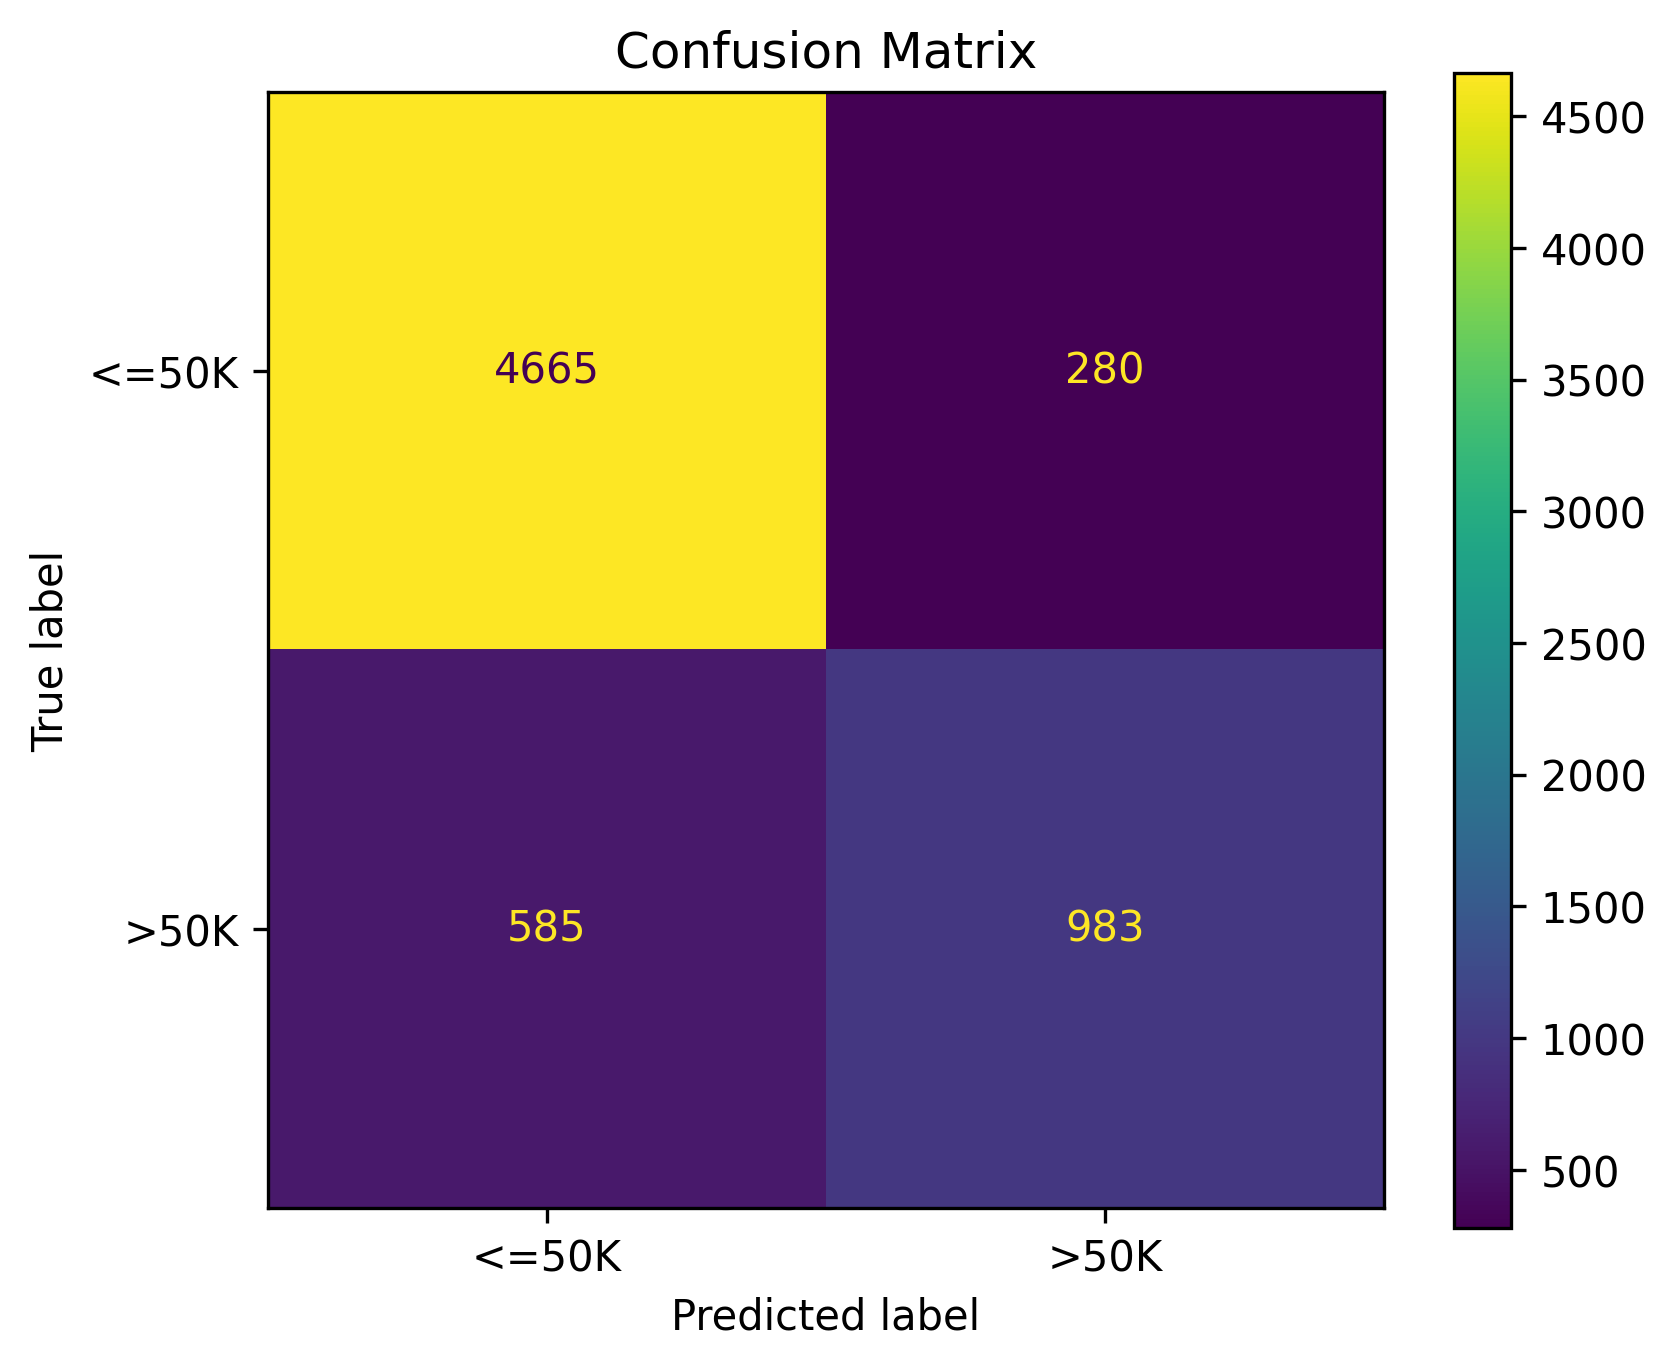

In [10]:
# | code-fold: true
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, class_labels)
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"]).plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

Plot the ROC curve. The ROC curve summarizes the trade-off between true positive rate and false positive rate as we vary the decision threshold.

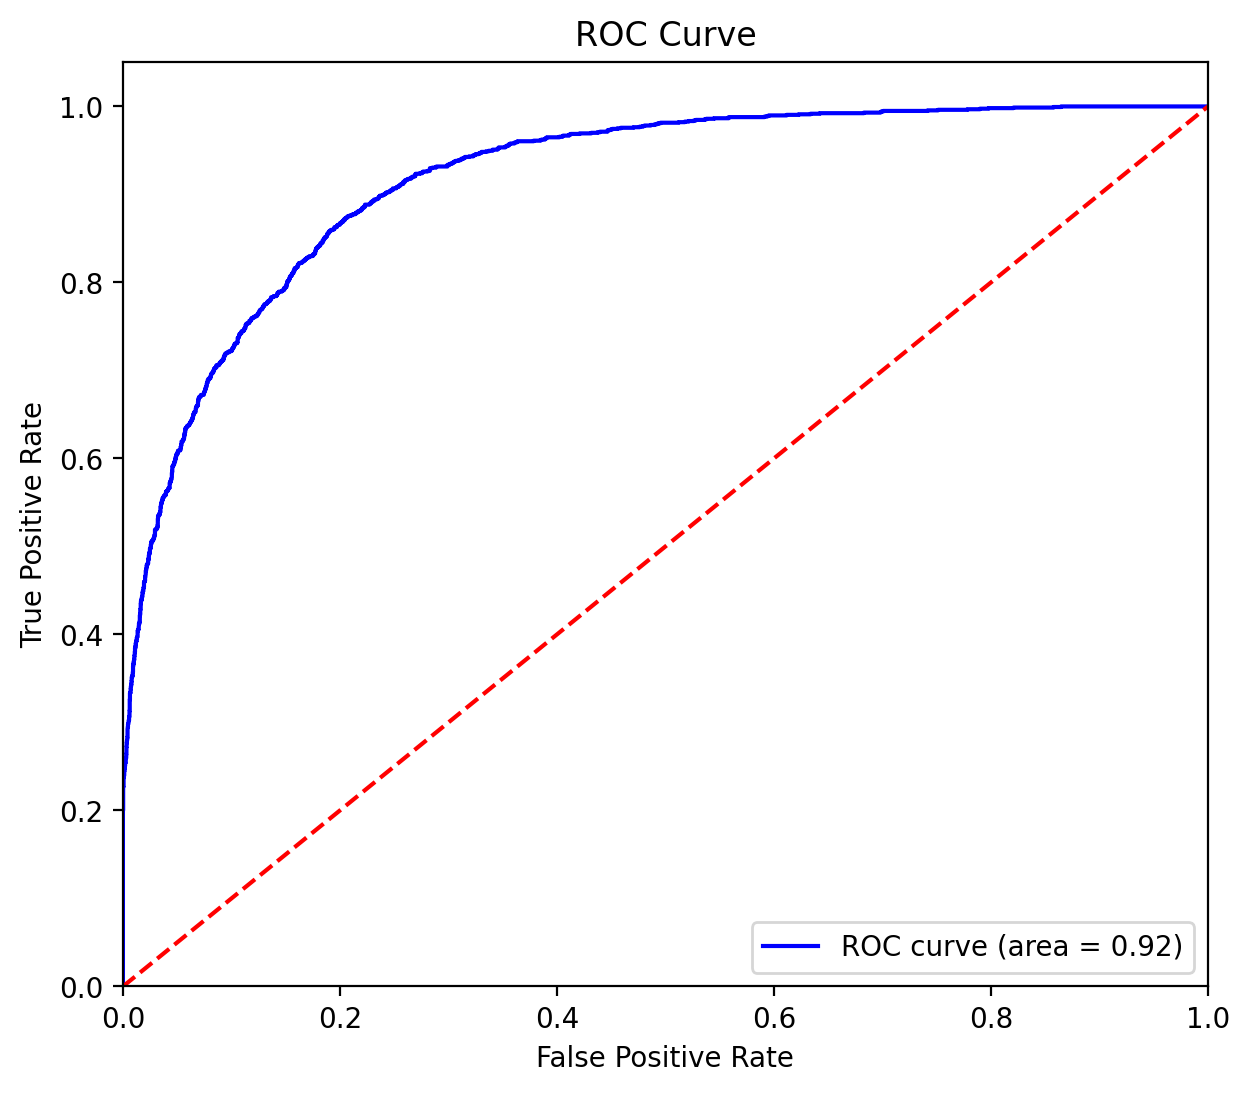

In [11]:
# | code-fold: true
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6), dpi=200)
plt.plot(fpr, tpr, color="blue", label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

Let's now train and evaluate an LightGBM model with similar hyperparameters.

In [12]:
%pip install lightgbm --quiet

import lightgbm as lgb

categorical_cols = list(X_train.select_dtypes(include=["object", "category"]).columns)

X_train2 = X_train.copy()
X_test2 = X_test.copy()
X_train2[categorical_cols] = X_train2[categorical_cols].astype("category")
for col in categorical_cols:
    X_test2[col] = pd.Categorical(X_test2[col], categories=X_train2[col].cat.categories)

lgb_train = lgb.Dataset(X_train2, y_train, categorical_feature=categorical_cols)
lgb_eval = lgb.Dataset(X_test2, y_test, reference=lgb_train, categorical_feature=categorical_cols)
lgbm = lgb.LGBMClassifier(
    objective="binary",
    learning_rate=0.1,
    n_estimators=50,
    num_leaves=20,
    max_depth=10,
    min_data_in_leaf=20,
    reg_lambda=0.0,
    data_sample_strategy="goss",
    top_rate=0.3,
    other_rate=0.1,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    seed=42,
    verbose=-1,
    path_smooth=0.6,
)
lgbm.fit(X_train2, y_train)


lgbm_test_probs = lgbm.predict_proba(X_test2)[:, 1]
class_labels = (lgbm_test_probs >= 0.5).astype(int)
f1 = f1_score(y_test, class_labels, average="binary")
roc_auc = roc_auc_score(y_test, lgbm_test_probs)
print(f"Test F1 Score: {trunc(f1)}")
print(f"Test ROC AUC Score: {trunc(roc_auc)}")

Note: you may need to restart the kernel to use updated packages.
Test F1 Score: 0.6999
Test ROC AUC Score: 0.9189


We can see they have similar performance. To make it complete let's include CatBoost in the comparison as well:

In [13]:
%pip install catboost --quiet

import catboost as cb

categorical_cols = list(X_train.select_dtypes(include=["object", "category"]).columns)

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()
for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].replace({np.nan: None}).astype(str)
    X_test_cb[col] = X_test_cb[col].replace({np.nan: None}).astype(str)

train_pool = cb.Pool(X_train_cb, y_train, cat_features=categorical_cols)
val_pool = cb.Pool(X_test_cb, y_test, cat_features=categorical_cols)

catboost_model = cb.CatBoostClassifier(
    loss_function="Logloss",
    iterations=50,
    learning_rate=0.1,
    depth=10,
    l2_leaf_reg=0.0,
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
)
catboost_model.fit(train_pool)


cb_test_probs = catboost_model.predict_proba(val_pool)[:, 1]
class_labels = (cb_test_probs >= 0.5).astype(int)
f1 = f1_score(y_test, class_labels, average="binary")
roc_auc = roc_auc_score(y_test, cb_test_probs)
print(f"Test F1 Score: {trunc(f1)}")
print(f"Test ROC AUC Score: {trunc(roc_auc)}")

Note: you may need to restart the kernel to use updated packages.
Test F1 Score: 0.6861
Test ROC AUC Score: 0.9162


The performance across all three implementations is comparable, demonstrating that our implementation captures the essential components of modern GBT algorithms while remaining simple and extensible.

## California Housing Price

This dataset contains information about house prices in California, including features like median income, average house age, average number of rooms, etc. The target variable is the median house value for each district. All features are numerical.

In [14]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X.head(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984126984126984,1.0238095238095237,322.0,2.5555555555555554,37.88,-122.23
1,8.3014,21.0,6.238137082601054,0.9718804920913884,2401.0,2.109841827768014,37.86,-122.22
2,7.2574,52.0,8.288135593220339,1.073446327683616,496.0,2.8022598870056497,37.85,-122.24
3,5.6431,52.0,5.8173515981735155,1.0730593607305936,558.0,2.547945205479452,37.85,-122.25
4,3.8462,52.0,6.281853281853282,1.0810810810810811,565.0,2.1814671814671813,37.85,-122.25
5,4.0368,52.0,4.761658031088083,1.1036269430051813,413.0,2.139896373056995,37.85,-122.25
6,3.6591,52.0,4.9319066147859925,0.9513618677042801,1094.0,2.1284046692607004,37.84,-122.25
7,3.12,52.0,4.797527047913447,1.061823802163833,1157.0,1.7882534775888717,37.84,-122.25
8,2.0804,42.0,4.294117647058823,1.1176470588235294,1206.0,2.026890756302521,37.84,-122.26
9,3.6912,52.0,4.970588235294118,0.9901960784313726,1551.0,2.172268907563025,37.84,-122.25


Split the data into training and testing sets, with stratification to ensure the target distribution is (somewhat) preserved in both sets.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=np.digitize(y, bins=np.histogram_bin_edges(y, bins=10)),
    test_size=0.2,
    random_state=42,
)

Fit the model to the training data using Gaussian distribution. By using `learn_variance=True`, the model will also learn to predict the variance of the target for heteroscedastic uncertainty estimation.

In [16]:
from src.gbm import GradientBoostedModel
from src.distributions import Gaussian

dist_normal = Gaussian(learn_variance=True)
gbm = GradientBoostedModel(
    learning_rate=0.1,
    n_trees=50,
    n_leaves=20,
    max_depth=10,
    max_bins=255,
    l2_regularization=0,
    min_weight_leaf=20,
    min_gain_to_split=0.0,
    goss_top_rate=0.3,
    goss_bottom_rate=0.1,
    seed=42,
    feature_fraction=0.9,
    samples_fraction=0.8,
    distribution=dist_normal,
    verbose=False,
)
gbm.fit(X_train, y_train);

  0%|          | 0/50 [00:00<?, ?it/s]

In [17]:
import numpy as np

# Shape (n_samples, 2), having (mean, stdev) for each sample
test_predictions = gbm.predict(X_test)
squared_errors = (test_predictions[:, 0] - y_test.values) ** 2
test_rmse = np.sqrt(np.mean(squared_errors))
print(f"Test RMSE: {trunc(test_rmse)}")

test_pearson = np.corrcoef(test_predictions[:, 0], y_test.values)[0, 1]
print(f"Test Pearson Correlation: {trunc(test_pearson)}")

Test RMSE: 0.48815
Test Pearson Correlation: 0.9103


Plot the calibration curve to visualize how well the predictions align with the true values across different ranges. Deviations from the line indicate regions where the model tends to under- or over-predict.

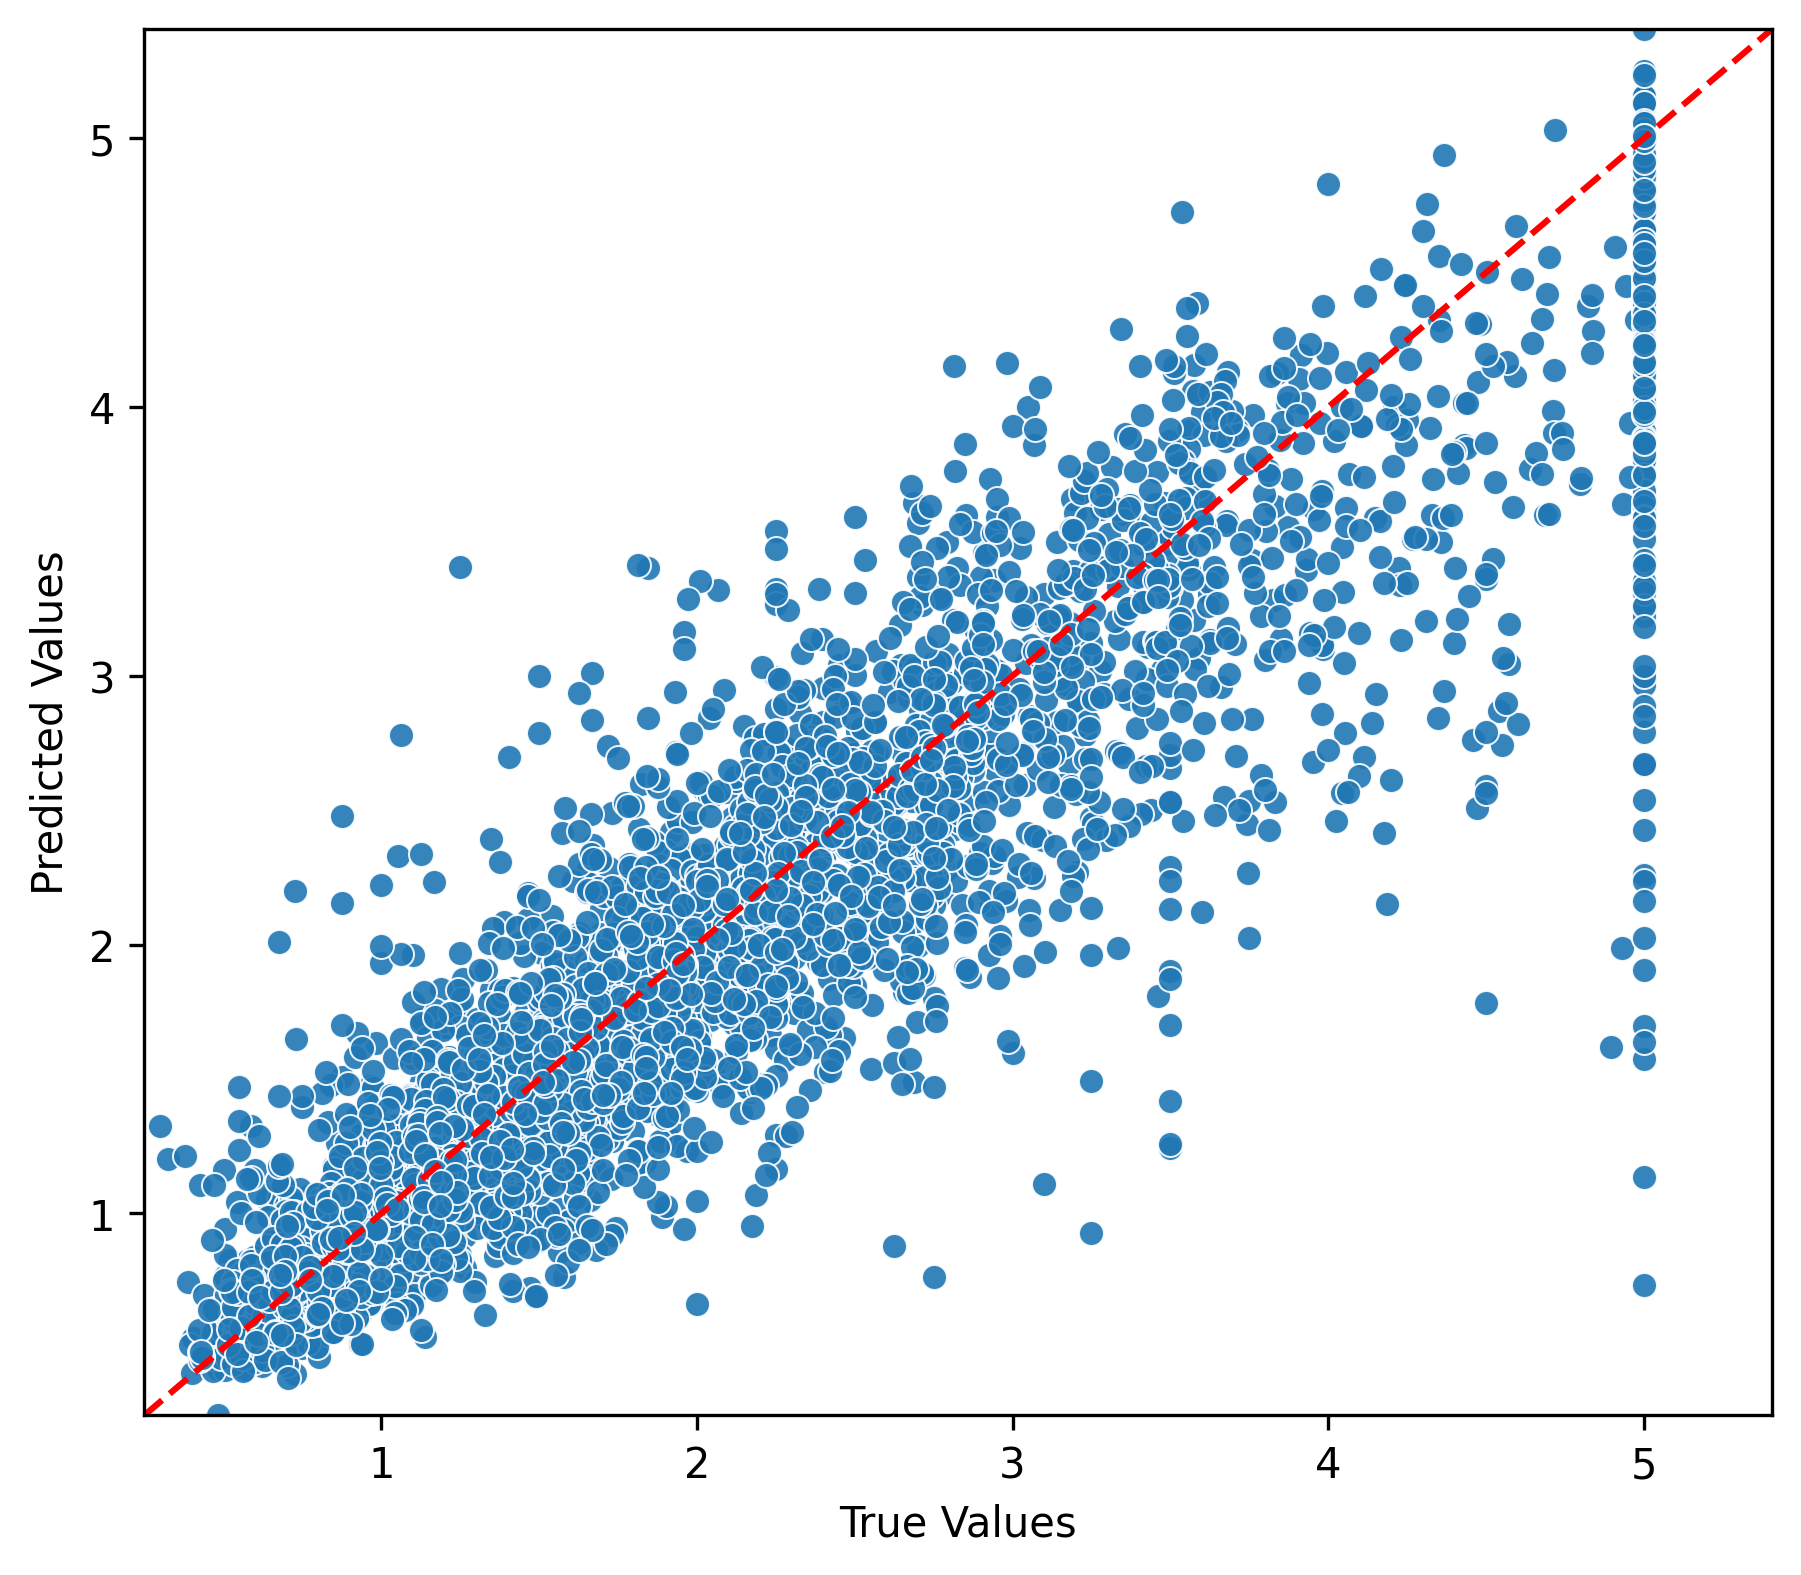

In [18]:
# | code-fold: true

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
# Calibration plot
sns.scatterplot(x=y_test, y=test_predictions[:, 0], alpha=0.9, ax=ax)
ax.set_xlabel("True Values")
ax.set_ylabel("Predicted Values")
# Set equal limits for x and y axes
min_val = min(y_test.min(), test_predictions[:, 0].min())
max_val = max(y_test.max(), test_predictions[:, 0].max())
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--");

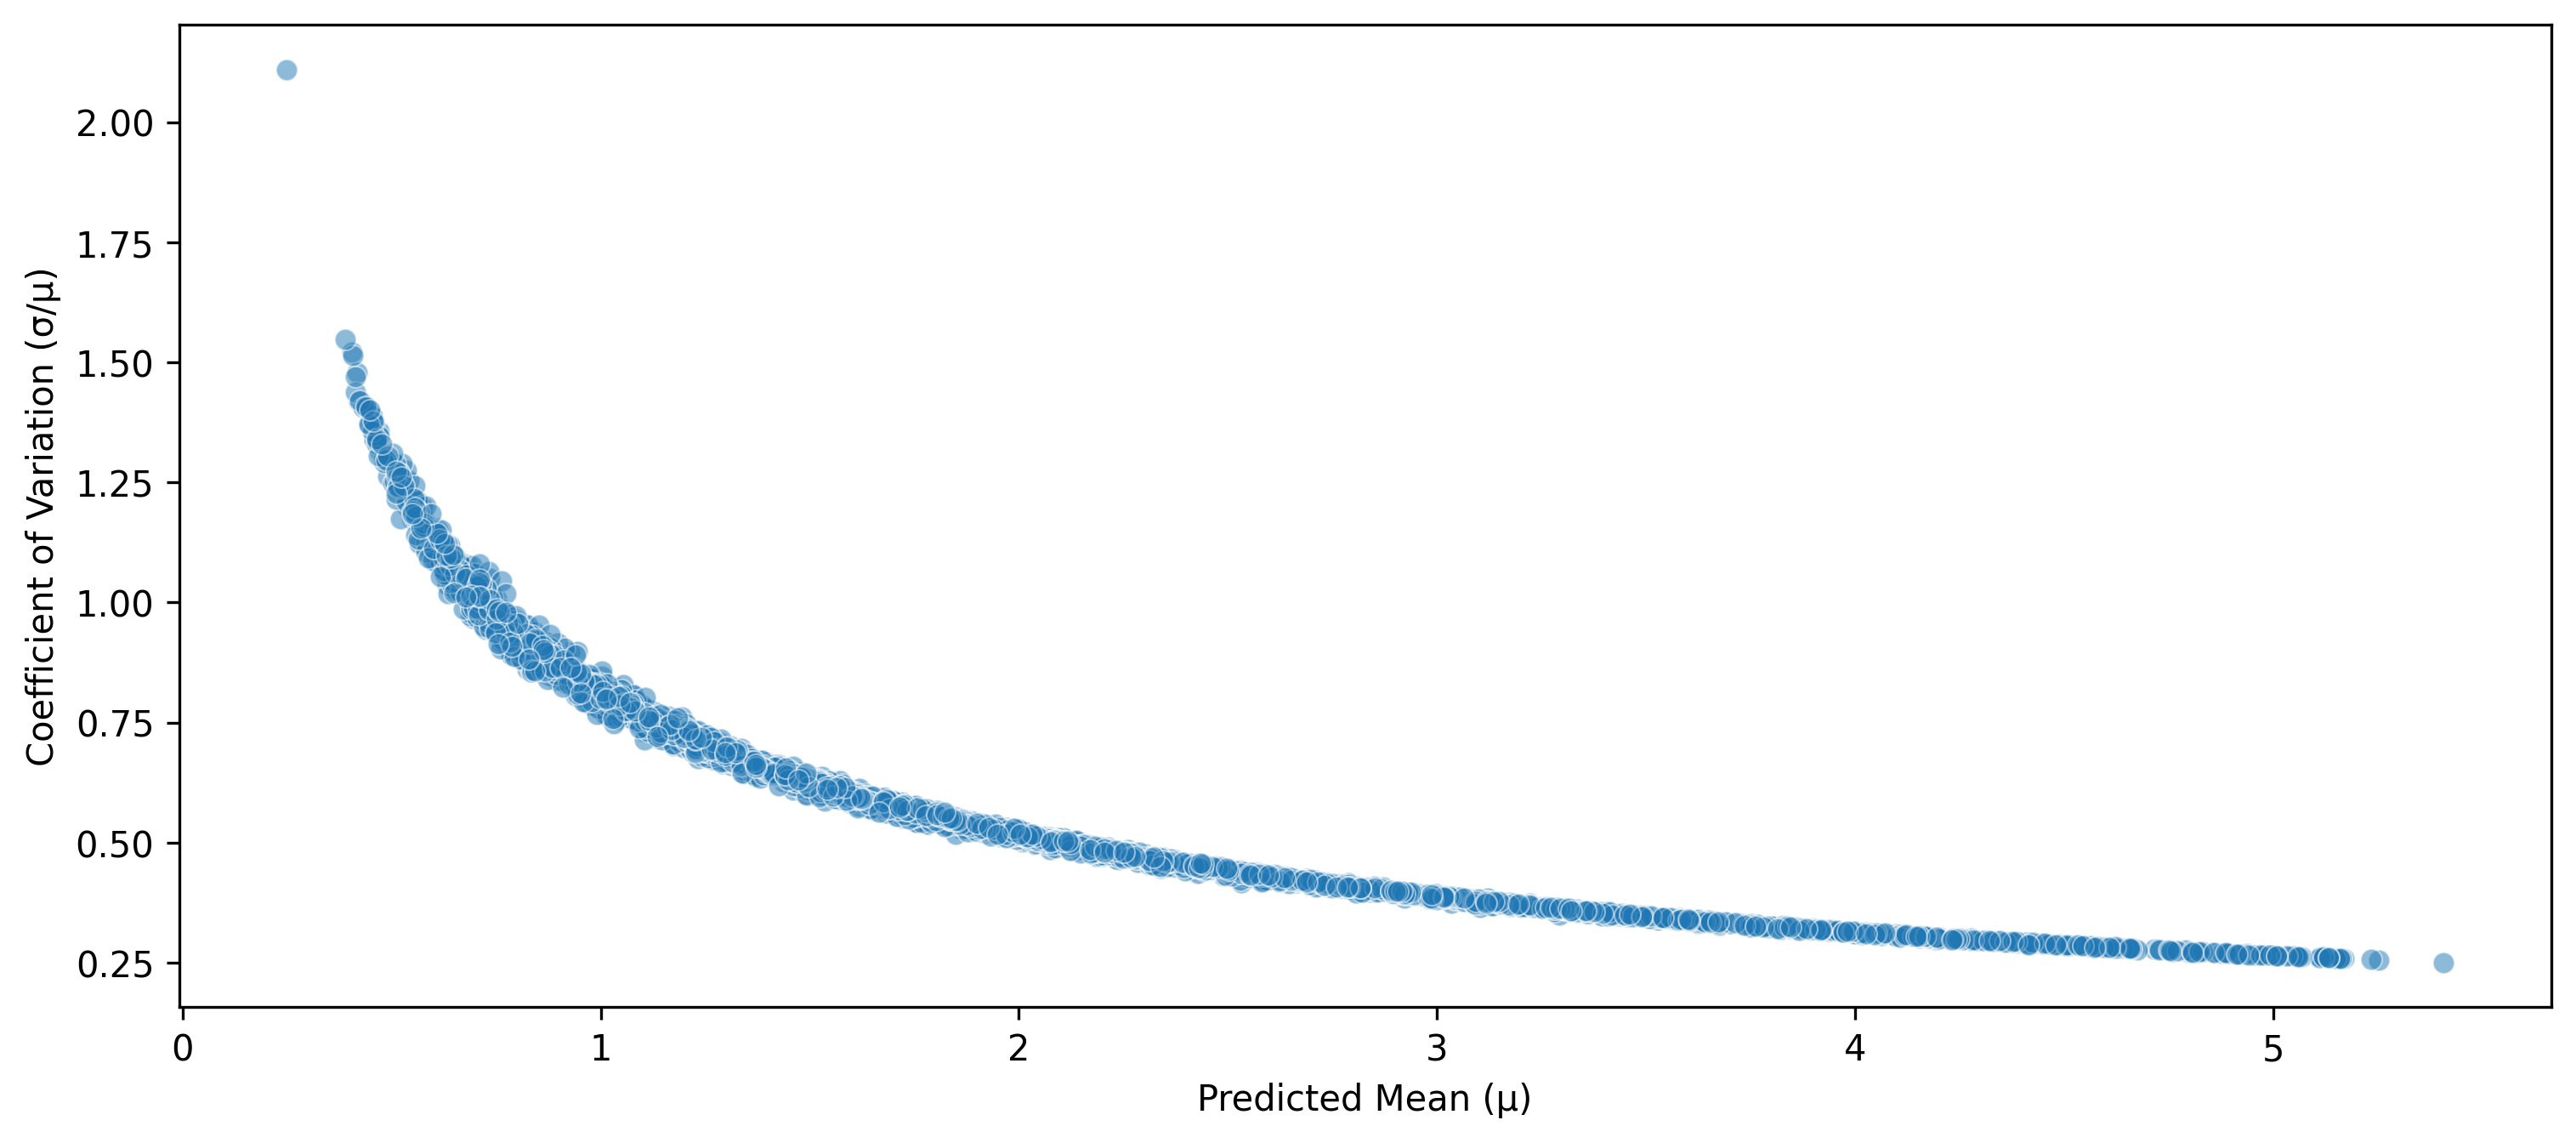

In [19]:
# | code-fold: true

mu, sigma = test_predictions.T
cv = sigma / mu

fig, ax = plt.subplots(figsize=(12, 5), dpi=300)
# mu-cv plot
sns.scatterplot(x=mu, y=cv, alpha=0.5, ax=ax)
ax.set_xlabel("Predicted Mean (μ)")
ax.set_ylabel("Coefficient of Variation (σ/μ)");